# SkillScope ID - Fine-tuning NER Skill Extraction

Notebook ini dibuat untuk dijalankan di Kaggle. Tujuannya adalah melatih model Named Entity Recognition untuk mengekstrak `HSkill`, `SSkill`, dan `Tech` dari lowongan kerja Indonesia, membandingkan IndoBERT dengan XLM-RoBERTa, mengevaluasi performa secara lengkap, lalu mengekspor model terbaik ke ONNX untuk web demo HTML/CSS/JS.

Catatan penting: notebook ini tidak menjanjikan akurasi tinggi secara absolut. Performa tinggi dikejar melalui split data yang benar, monitoring validation metrics, early stopping, checkpoint terbaik, evaluasi test set, error analysis, dan validasi ONNX.

## 0. Setup Kaggle

Cell ini menyiapkan dependency yang dibutuhkan. Di Kaggle sebagian package biasanya sudah tersedia, tetapi install eksplisit membuat notebook lebih reproducible. Jika dependency sudah lengkap, cell ini tetap aman dijalankan.

In [1]:
!pip -q install --no-cache-dir transformers datasets evaluate seqeval accelerate scikit-learn pandas numpy matplotlib seaborn onnx onnxruntime "optimum[onnxruntime]"
!pip cache purge 2>/dev/null || true

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 244.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 215.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 366.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 214.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 238.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 355.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda

## 1. Import Library

Cell ini memuat library untuk parsing dataset, EDA, training HuggingFace Trainer, evaluasi NER, visualisasi, dan export ONNX.

In [2]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from IPython.display import display
from onnxruntime.quantization import QuantType, quantize_dynamic
from optimum.onnxruntime import ORTModelForTokenClassification
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid", context="notebook")

2026-06-20 18:19:11.772454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781979552.190620      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781979552.305480      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781979553.297483      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781979553.297524      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781979553.297527      23 computation_placer.cc:177] computation placer alr

## 2. Konfigurasi Eksperimen

Ubah `DATA_PATH` sesuai lokasi dataset NERSkill.Id di Kaggle. Output eksperimen disimpan ke `/kaggle/working/outputs` agar mudah di-download setelah notebook selesai.

In [3]:
SEED = 42
DATA_PATH = Path("/kaggle/input/datasets/maidilfitrah/nerskill-id")
OUTPUT_DIR = Path("/kaggle/working/outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
REPORTS_DIR = OUTPUT_DIR / "reports"
MODELS_DIR = OUTPUT_DIR / "models"
ONNX_DIR = OUTPUT_DIR / "onnx"
WEB_MODEL_DIR = OUTPUT_DIR / "web_model"

for directory in [OUTPUT_DIR, PLOTS_DIR, REPORTS_DIR, MODELS_DIR, ONNX_DIR, WEB_MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# [UPGRADE] Kedua model dinaikkan ke varian Large untuk kapasitas representasi yang lebih tinggi.
# - indobert-large-p2: 335M params, standar industri NLP Indonesia.
# - NusaBERT-large: 335M params, IndoBERT yang di-pretrain ulang dengan 16 miliar token
#   dari Wikipedia ID, KoPI-NLLB, dan CulturaX. Mendukung 13 bahasa Nusantara.
MODEL_CONFIGS = {
    "indobert": "indobenchmark/indobert-large-p2",
    "nusabert": "LazarusNLP/NusaBERT-large",
}

LABEL_LIST = ["O", "B-HSkill", "I-HSkill", "B-SSkill", "I-SSkill", "B-Tech", "I-Tech"]
LABEL2ID = {label: idx for idx, label in enumerate(LABEL_LIST)}
ID2LABEL = {idx: label for label, idx in LABEL2ID.items()}
ENTITY_TYPES = ["HSkill", "SSkill", "Tech"]

# [FIX v6] MAX_LENGTH diturunkan ke 128:
# - 97.35% kalimat dataset di bawah 128 token (hanya 2.65% terpotong)
# - Mengurangi waktu per epoch ~2x dibanding 256
# - Sebelumnya MAX_LENGTH=256 menyebabkan timeout 12 jam di Kaggle
MAX_LENGTH = 128
LABEL_ALL_TOKENS = True

B_TO_I_MAP = {
    "B-HSkill": "I-HSkill", "B-SSkill": "I-SSkill", "B-Tech": "I-Tech",
}

TRAIN_SIZE = 0.80
VALIDATION_SIZE = 0.10
TEST_SIZE = 0.10

# [FIX v6] Hyperparameter dioptimasi agar 2 model Large bisa selesai dalam ~2.5 jam:
#
# MASALAH SEBELUMNYA (Patch v5):
#   batch=4, accum=4, checkpointing=True, epochs=15, MAX_LENGTH=256
#   → 57 menit/epoch × 15 epoch = 14+ jam → TIMEOUT
#
# SOLUSI:
#   batch=8       : 2x lebih sedikit forward pass per epoch
#   accum=1       : efektif batch = 8 × 2 GPU = 16 (cukup stabil)
#   epochs=10     : andalkan early stopping, bukan epoch mentah
#   patience=3    : berhenti lebih cepat jika F1 sudah plateau
#   checkpointing : TETAP True (wajib agar batch=8 + Large model tidak OOM)
#   MAX_LENGTH=128: ~2x lebih cepat per step (sesuai analisis distribusi dataset)
#
# Estimasi: ~10 menit/epoch × ~7 epoch (early stop) × 2 model = ~2.5 jam total
TRAINING_CONFIG = {
    "learning_rate": 2e-5,
    "num_train_epochs": 10,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 16,
    "gradient_accumulation_steps": 1,
    "gradient_checkpointing": True,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "max_grad_norm": 1.0,
    "early_stopping_patience": 3,
    "save_total_limit": 1,
}

def check_cuda_runtime() -> tuple[bool, str]:
    if not torch.cuda.is_available():
        return False, "CUDA tidak tersedia. Aktifkan GPU di Kaggle Settings -> Accelerator."
    try:
        device = torch.device("cuda")
        probe = torch.tensor([1, 2, 3], device=device)
        _ = (probe + 1).detach().cpu().numpy()
        torch.cuda.synchronize()
        return True, "CUDA siap digunakan."
    except Exception as exc:
        return False, f"CUDA terdeteksi tetapi gagal: {exc}"

CUDA_OK, CUDA_MESSAGE = check_cuda_runtime()
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
CUDA_VERSION = torch.version.cuda
USE_FP16 = CUDA_OK and any(name in GPU_NAME.upper() for name in ["T4", "V100", "A100", "L4"])

print("Torch version:", torch.__version__)
print("Torch CUDA build:", CUDA_VERSION)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", GPU_NAME)
print("CUDA status:", CUDA_MESSAGE)
print("Use fp16:", USE_FP16)

if not CUDA_OK:
    raise RuntimeError(CUDA_MESSAGE)

Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
CUDA status: CUDA siap digunakan.
Use fp16: True


## 3. Reproducibility

Seed dibuat tetap agar split dan eksperimen lebih mudah direproduksi. Deterministic mode penuh tidak dipaksa karena bisa memperlambat training GPU, tetapi seed dasar tetap dikunci.

In [4]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(SEED)

experiment_config = {
    "seed": SEED,
    "data_path": str(DATA_PATH),
    "models": MODEL_CONFIGS,
    "label_list": LABEL_LIST,
    "max_length": MAX_LENGTH,
    "training_config": TRAINING_CONFIG,
}
(OUTPUT_DIR / "experiment_config.json").write_text(json.dumps(experiment_config, indent=2), encoding="utf-8")

711

## 4. Load Dataset CoNLL/BIO

Parser dibuat fleksibel untuk dua format umum: `token tag` dan `sentence_id token tag`. Header otomatis dilewati jika terdeteksi. Validasi label dilakukan sejak awal agar error dataset tidak masuk diam-diam ke training.

In [5]:
def resolve_dataset_file(path: Path) -> Path:
    """Return a dataset file path even when DATA_PATH points to a Kaggle input directory."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset tidak ditemukan: {path}. Ubah DATA_PATH sesuai path Kaggle dataset.")

    if path.is_file():
        return path

    candidates = []
    allowed_suffixes = {".txt", ".tsv", ".csv", ".conll"}
    for candidate in path.rglob("*"):
        if candidate.is_file() and candidate.suffix.lower() in allowed_suffixes:
            candidates.append(candidate)

    if not candidates:
        visible_files = [str(item) for item in path.rglob("*") if item.is_file()][:20]
        raise FileNotFoundError(
            "DATA_PATH mengarah ke folder, tetapi tidak ditemukan file dataset "
            f"dengan ekstensi {sorted(allowed_suffixes)} di {path}. "
            f"File yang terlihat: {visible_files}"
        )

    preferred = sorted(
        candidates,
        key=lambda item: (
            "nerskill" not in item.name.lower(),
            item.suffix.lower() not in {".txt", ".tsv"},
            len(str(item)),
        ),
    )[0]
    print(f"DATA_PATH adalah folder. Menggunakan file dataset: {preferred}")
    return preferred


def parse_conll(path: Path) -> list[dict[str, list[str]]]:
    path = resolve_dataset_file(path)

    records = []
    tokens, tags = [], []
    skipped_header = False
    previous_sentence_id = None

    def flush_sentence():
        nonlocal tokens, tags
        if tokens:
            records.append({"tokens": tokens, "ner_tags": tags})
            tokens, tags = [], []

    with path.open("r", encoding="utf-8") as handle:
        for line_number, raw_line in enumerate(handle, start=1):
            line = raw_line.strip()
            if not line:
                flush_sentence()
                previous_sentence_id = None
                continue

            parts = line.split("\t") if "\t" in line else line.split()
            lowered = [part.lower() for part in parts]
            if not skipped_header and any(name in lowered for name in ["word", "token", "tag"]):
                skipped_header = True
                continue

            if len(parts) < 2:
                raise ValueError(f"Baris tidak valid di line {line_number}: {raw_line!r}")

            tag = parts[-1].strip()
            if len(parts) >= 4 and parts[0].lower().startswith("sentence"):
                sentence_id = f"{parts[0]} {parts[1]}"
            elif len(parts) >= 3:
                sentence_id = parts[0].strip()
            else:
                sentence_id = None
            token = parts[-2].strip() if len(parts) >= 3 else parts[0].strip()

            if tag not in LABEL2ID:
                raise ValueError(f"Label tidak dikenal {tag!r} di line {line_number}")

            if sentence_id is not None and previous_sentence_id is not None and sentence_id != previous_sentence_id:
                flush_sentence()
            if sentence_id is not None:
                previous_sentence_id = sentence_id

            if token:
                tokens.append(token)
                tags.append(tag)

    flush_sentence()

    if not records:
        raise ValueError("Dataset kosong setelah parsing.")
    if len(records) < 3:
        raise ValueError(
            f"Dataset hanya terbaca sebagai {len(records)} kalimat. "
            "Kemungkinan format kolom belum sesuai. Cek apakah dataset memakai kolom Sentence/Word/Tag, "
            "dan pastikan parser memisahkan kalimat berdasarkan sentence id atau baris kosong."
        )

    return records


records = parse_conll(DATA_PATH)
total_tokens = sum(len(row["tokens"]) for row in records)
print(f"Total sentences: {len(records):,}")
print(f"Total tokens: {total_tokens:,}")
display(pd.DataFrame(records[:3]))

DATA_PATH adalah folder. Menggunakan file dataset: /kaggle/input/datasets/maidilfitrah/nerskill-id/NERSkill.Id.txt
Total sentences: 4,299
Total tokens: 418,868


,tokens,ner_tags
0,"[Pendidikan, minimal, S1, dari, Jurusan, Tekni...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
1,"[Sarjana, (, S1, ), ., Menguasai, bahasa, prog...","[O, O, O, O, O, O, O, B-Tech, I-Tech, O, O, O,..."
2,"[Pendidikan, minimal, S1, dari, Jurusan, Tekni...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."


## 5. Helper EDA Entitas BIO

Cell ini mengubah urutan token-label menjadi span entitas utuh. Hasilnya dipakai untuk analisis distribusi entity, panjang span, frasa paling sering, dan error analysis.

In [6]:
def bio_to_entities(tokens: list[str], tags: list[str]) -> list[dict[str, object]]:
    entities = []
    current = None

    for idx, (token, tag) in enumerate(zip(tokens, tags)):
        if tag == "O":
            if current:
                entities.append(current)
                current = None
            continue

        prefix, entity_type = tag.split("-", 1)
        should_start = prefix == "B" or current is None or current["type"] != entity_type

        if should_start:
            if current:
                entities.append(current)
            current = {"type": entity_type, "tokens": [token], "start": idx, "end": idx}
        else:
            current["tokens"].append(token)
            current["end"] = idx

    if current:
        entities.append(current)

    for entity in entities:
        entity["text"] = " ".join(entity["tokens"])
        entity["length"] = len(entity["tokens"])
    return entities


entity_rows = []
for sentence_id, row in enumerate(records):
    for entity in bio_to_entities(row["tokens"], row["ner_tags"]):
        entity_rows.append({"sentence_id": sentence_id, **entity})

entities_df = pd.DataFrame(entity_rows)
display(entities_df.head(10))
print(f"Total entities: {len(entities_df):,}")

,sentence_id,type,tokens,start,end,text,length
0,0,HSkill,[pemrograman],17,17,pemrograman,1
1,0,HSkill,"[web-based, application]",21,22,web-based application,2
2,0,Tech,[Javascript],24,24,Javascript,1
3,0,Tech,[CSS3],26,26,CSS3,1
4,0,Tech,"[Vue, JS]",29,30,Vue JS,2
5,0,HSkill,[SQL],38,38,SQL,1
6,0,Tech,[API],42,42,API,1
7,0,Tech,"[SoAP, Web, Service]",44,46,SoAP Web Service,3
8,0,HSkill,[Programmer],48,48,Programmer,1
9,0,Tech,[PHP],49,49,PHP,1


Total entities: 45,508


## 6. EDA Ringkasan Dataset

Cell ini membuat statistik dasar yang akan dipakai pada laporan: jumlah kalimat, jumlah token, jumlah entitas, rata-rata panjang kalimat, dan distribusi label BIO.

In [7]:
sentence_lengths = pd.Series([len(row["tokens"]) for row in records], name="sentence_length")
flat_tags = [tag for row in records for tag in row["ner_tags"]]
label_counts = pd.Series(flat_tags).value_counts().reindex(LABEL_LIST, fill_value=0)
entity_counts = entities_df["type"].value_counts().reindex(ENTITY_TYPES, fill_value=0) if not entities_df.empty else pd.Series(0, index=ENTITY_TYPES)

summary = {
    "total_sentences": int(len(records)),
    "total_tokens": int(total_tokens),
    "total_entities": int(len(entities_df)),
    "avg_sentence_length": float(sentence_lengths.mean()),
    "median_sentence_length": float(sentence_lengths.median()),
    "max_sentence_length": int(sentence_lengths.max()),
    "label_counts": {label: int(count) for label, count in label_counts.items()},
    "entity_counts": {label: int(count) for label, count in entity_counts.items()},
}

(OUTPUT_DIR / "dataset_stats.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
display(pd.DataFrame([summary]).drop(columns=["label_counts", "entity_counts"]))
display(label_counts.to_frame("token_count"))
display(entity_counts.to_frame("entity_count"))

,total_sentences,total_tokens,total_entities,avg_sentence_length,median_sentence_length,max_sentence_length
0,4299,418868,45508,97.433822,84.0,633


,token_count
O,353888
B-HSkill,17009
I-HSkill,11508
B-SSkill,10891
I-SSkill,3858
B-Tech,17300
I-Tech,4414


,entity_count
type,
HSkill,17113
SSkill,11062
Tech,17333


## 7. Visualisasi EDA: Label dan Entity

Visualisasi ini membantu menjelaskan apakah dataset imbalanced. Jika label `O` jauh dominan, F1 entity-level lebih penting daripada token accuracy karena token accuracy bisa terlihat tinggi walaupun model melewatkan entitas.

/tmp/ipykernel_23/1200478106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette="viridis")
/tmp/ipykernel_23/1200478106.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=entity_counts.index, y=entity_counts.values, ax=axes[1], palette="crest")


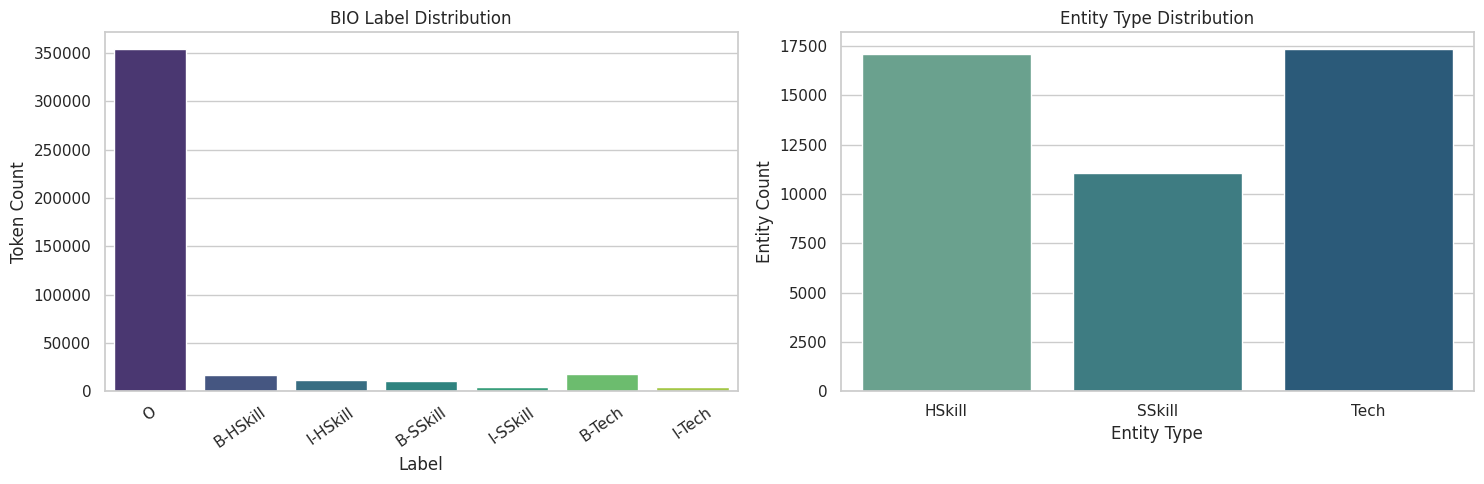

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("BIO Label Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Token Count")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(x=entity_counts.index, y=entity_counts.values, ax=axes[1], palette="crest")
axes[1].set_title("Entity Type Distribution")
axes[1].set_xlabel("Entity Type")
axes[1].set_ylabel("Entity Count")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "label_and_entity_distribution.png", dpi=180)
plt.show()

## 8. Visualisasi EDA: Panjang Kalimat dan Span Entitas

Analisis panjang kalimat digunakan untuk menentukan `MAX_LENGTH`. Jika banyak kalimat melewati 128 token, naikkan `MAX_LENGTH` ke 256 agar konteks tidak banyak terpotong.

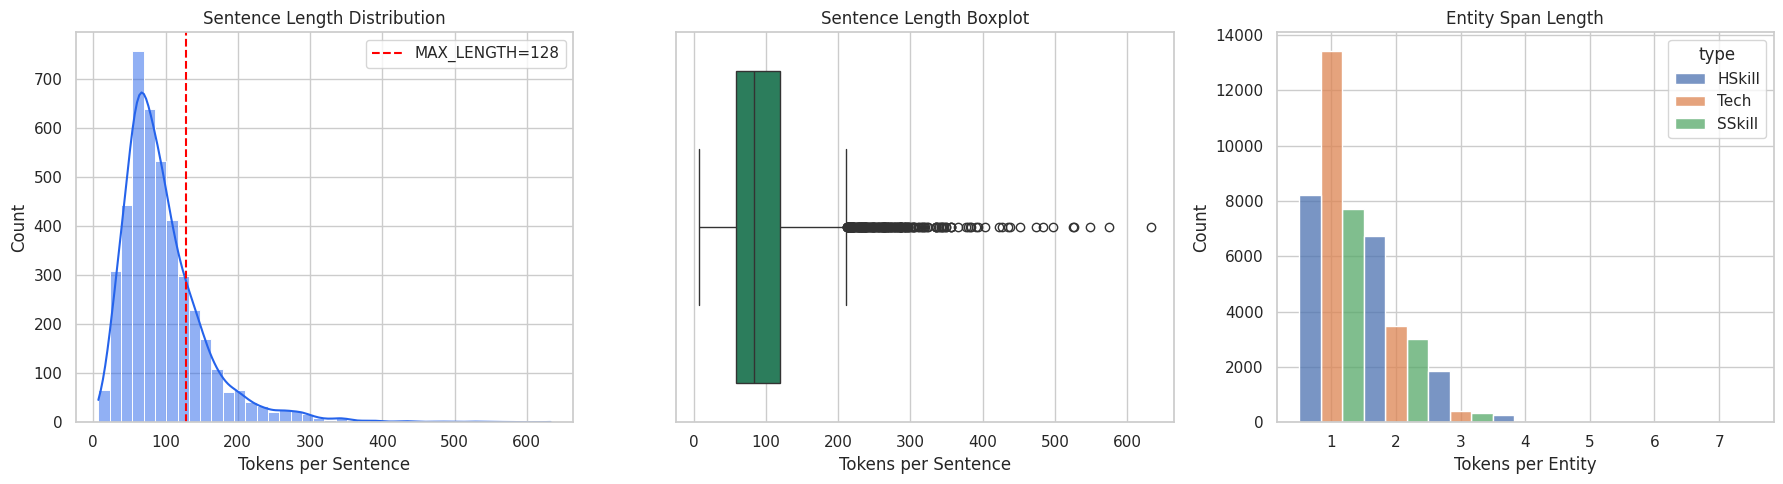

Sentences longer than MAX_LENGTH=128: 21.26%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(sentence_lengths, bins=40, kde=True, ax=axes[0], color="#2563eb")
axes[0].axvline(MAX_LENGTH, color="red", linestyle="--", label=f"MAX_LENGTH={MAX_LENGTH}")
axes[0].set_title("Sentence Length Distribution")
axes[0].set_xlabel("Tokens per Sentence")
axes[0].legend()

sns.boxplot(x=sentence_lengths, ax=axes[1], color="#1f8a5f")
axes[1].set_title("Sentence Length Boxplot")
axes[1].set_xlabel("Tokens per Sentence")

if not entities_df.empty:
    sns.histplot(data=entities_df, x="length", hue="type", multiple="dodge", discrete=True, ax=axes[2])
axes[2].set_title("Entity Span Length")
axes[2].set_xlabel("Tokens per Entity")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "length_distributions.png", dpi=180)
plt.show()

truncation_rate = float((sentence_lengths > MAX_LENGTH).mean())
print(f"Sentences longer than MAX_LENGTH={MAX_LENGTH}: {truncation_rate:.2%}")

## 9. Visualisasi EDA: Top Entity Phrases

Cell ini menampilkan frasa entitas yang paling sering muncul. Ini berguna untuk memahami vocabulary domain dan menyiapkan contoh demo presentasi.

,type,text_norm,count
2905,HSkill,pemrograman,589
4032,HSkill,software,461
1611,HSkill,jaringan,446
727,HSkill,database,420
3271,HSkill,perangkat lunak,339
1280,HSkill,hardware,298
4154,HSkill,sql,251
3495,HSkill,programmer,225
4503,HSkill,troubleshooting,190
2695,HSkill,oop,162


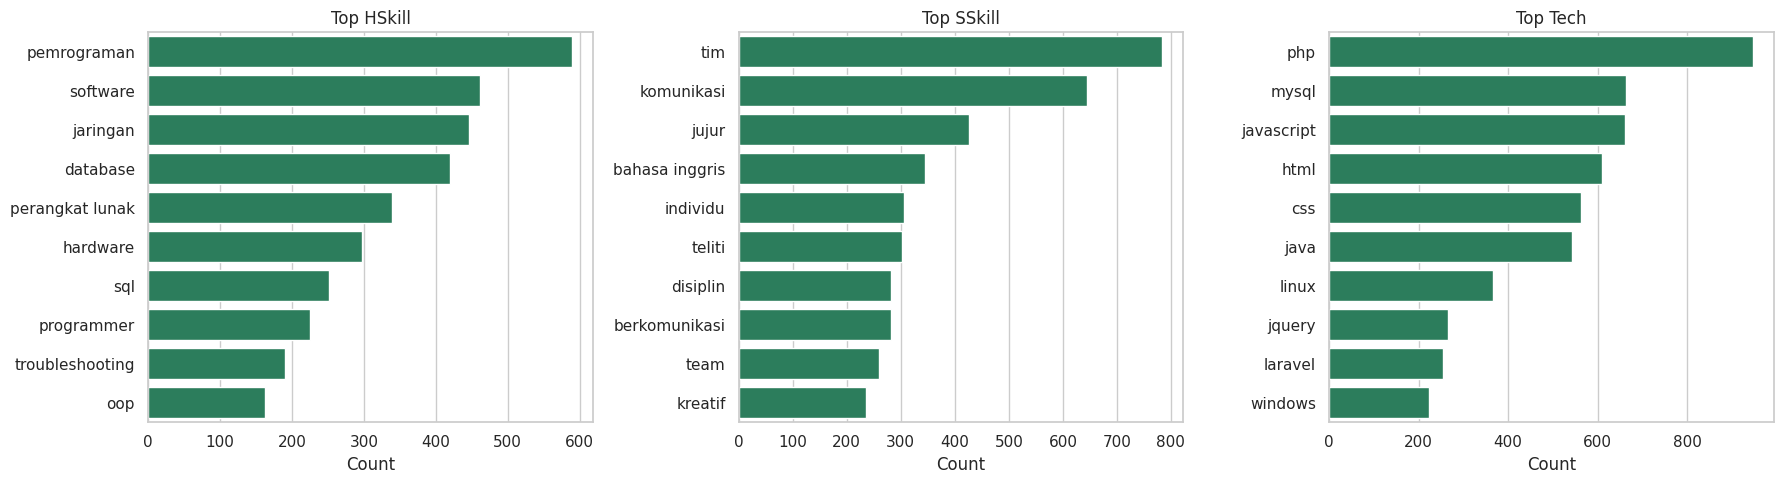

In [10]:
if not entities_df.empty:
    top_entities = (
        entities_df.assign(text_norm=entities_df["text"].str.lower())
        .groupby(["type", "text_norm"])
        .size()
        .reset_index(name="count")
        .sort_values(["type", "count"], ascending=[True, False])
    )
    display(top_entities.groupby("type").head(10))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, entity_type in zip(axes, ENTITY_TYPES):
        subset = top_entities[top_entities["type"] == entity_type].head(10)
        sns.barplot(data=subset, y="text_norm", x="count", ax=ax, color="#1f8a5f")
        ax.set_title(f"Top {entity_type}")
        ax.set_xlabel("Count")
        ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "top_entity_phrases.png", dpi=180)
    plt.show()
else:
    print("Tidak ada entitas untuk divisualisasikan.")

## 10. Split Train/Validation/Test

Split dilakukan pada level kalimat, bukan token, agar konteks satu kalimat tidak bocor ke split lain. Test set tidak boleh dipakai untuk tuning; hanya untuk evaluasi final.

In [11]:
# === Split Data (No Augmentation — Back to Basics) ===
# Eksperimen sebelumnya menunjukkan bahwa augmentasi (sinonim, shuffle, entity replace)
# justru menambah noise dan menurunkan F1. Kita andalkan kapasitas model Large.

train_raw, temp_raw = train_test_split(records, test_size=0.20, random_state=SEED, shuffle=True)
val_raw, test_raw = train_test_split(temp_raw, test_size=0.50, random_state=SEED, shuffle=True)
print(f"Train: {len(train_raw)}, Val: {len(val_raw)}, Test: {len(test_raw)}")

def _enc(recs):
    return [{"tokens": r["tokens"], "ner_tags": [LABEL2ID[t] for t in r["ner_tags"]]} for r in recs]

train_records = _enc(train_raw)
validation_records = _enc(val_raw)
test_records = _enc(test_raw)

raw_dataset = DatasetDict({
    "train": Dataset.from_list(train_records),
    "validation": Dataset.from_list(validation_records),
    "test": Dataset.from_list(test_records),
})
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "sentences": [len(train_records), len(validation_records), len(test_records)],
    "tokens": [sum(len(r["tokens"]) for r in s) for s in [train_records, validation_records, test_records]],
})
split_summary["sentence_pct"] = split_summary["sentences"] / split_summary["sentences"].sum()
display(split_summary)
raw_dataset

Train: 3439, Val: 430, Test: 430


,split,sentences,tokens,sentence_pct
0,train,3439,334676,0.799953
1,validation,430,41869,0.100023
2,test,430,42323,0.100023


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3439
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 430
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 430
    })
})

## 11. Visualisasi Distribusi Label per Split

Cell ini memastikan distribusi label di train, validation, dan test tidak terlalu berbeda. Perbedaan ekstrem dapat membuat evaluasi tidak stabil.

,O,B-HSkill,I-HSkill,B-SSkill,I-SSkill,B-Tech,I-Tech
train,282732,13529,9111,8814,3168,13724,3598
validation,35460,1731,1120,1034,353,1794,377
test,35696,1749,1277,1043,337,1782,439


<Figure size 1300x500 with 0 Axes>

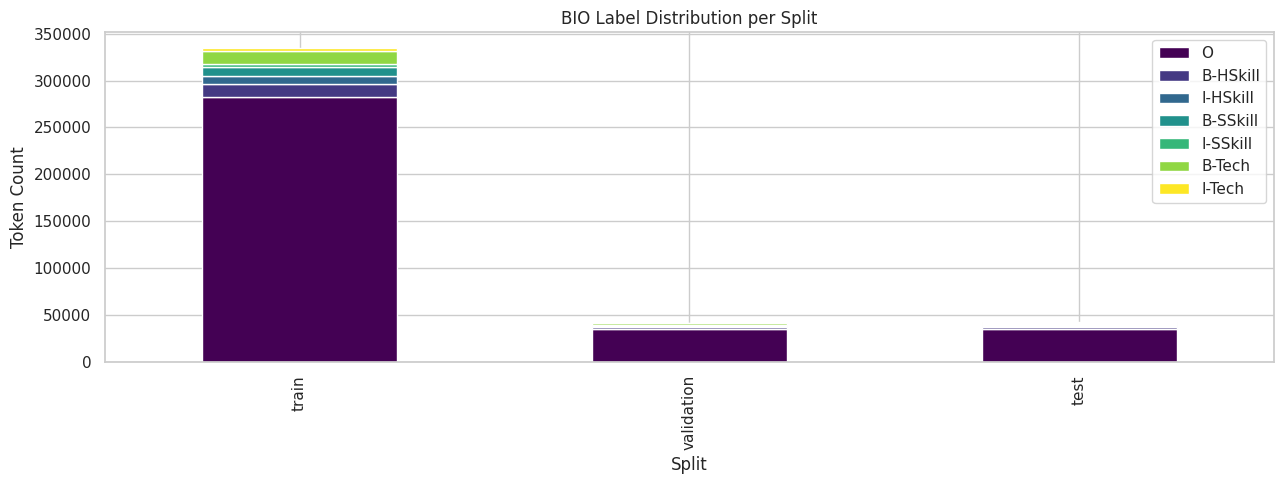

In [12]:
def split_label_counts(split_records: list[dict]) -> pd.Series:
    labels = [ID2LABEL[tag_id] for row in split_records for tag_id in row["ner_tags"]]
    return pd.Series(labels).value_counts().reindex(LABEL_LIST, fill_value=0)


split_label_df = pd.DataFrame({
    "train": split_label_counts(train_records),
    "validation": split_label_counts(validation_records),
    "test": split_label_counts(test_records),
}).T
display(split_label_df)

plt.figure(figsize=(13, 5))
split_label_df.plot(kind="bar", stacked=True, figsize=(13, 5), colormap="viridis")
plt.title("BIO Label Distribution per Split")
plt.xlabel("Split")
plt.ylabel("Token Count")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "split_label_distribution.png", dpi=180)
plt.show()

## 12. Tokenization dan Label Alignment

Transformer memakai subword tokenization. Label BIO hanya diberikan ke subword pertama; special token dan subword lanjutan diberi `-100` agar diabaikan oleh loss function. Ini penting agar training tidak rusak.

In [13]:
def tokenize_and_align_dataset(dataset: DatasetDict, model_name: str, max_length: int = MAX_LENGTH):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tokenize_and_align_labels(examples):
        tokenized = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True, max_length=max_length)
        labels = []
        for i, wl in enumerate(examples["ner_tags"]):
            wids = tokenized.word_ids(batch_index=i)
            aligned, prev = [], None
            for wid in wids:
                if wid is None: aligned.append(-100)
                elif wid != prev: aligned.append(wl[wid])
                else:
                    if LABEL_ALL_TOKENS:
                        aligned.append(B_TO_I_MAP.get(wl[wid], wl[wid]))
                    else:
                        aligned.append(-100)
                prev = wid
            labels.append(aligned)
        tokenized["labels"] = labels
        return tokenized
    return tokenizer, dataset.map(tokenize_and_align_labels, batched=True)

## 13. Sanity Check Token Alignment

Cell ini wajib dicek sebelum training. Jika label tidak sejajar dengan token, metrik bisa terlihat buruk atau tidak valid.

In [14]:
debug_tokenizer, debug_tokenized = tokenize_and_align_dataset(raw_dataset, MODEL_CONFIGS["indobert"], MAX_LENGTH)
sample = debug_tokenized["train"][0]
tokens = debug_tokenizer.convert_ids_to_tokens(sample["input_ids"])
aligned_labels = [ID2LABEL[label] if label != -100 else "IGN" for label in sample["labels"]]
alignment_preview = pd.DataFrame({"token": tokens, "label": aligned_labels, "attention_mask": sample["attention_mask"]})
display(alignment_preview.head(40))

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/3439 [00:00<?, ? examples/s]

Map:   0%|          | 0/430 [00:00<?, ? examples/s]

Map:   0%|          | 0/430 [00:00<?, ? examples/s]

,token,label,attention_mask
0,[CLS],IGN,1
1,friends,O,1
2,##hip,O,1
3,logis,O,1
4,##tics,O,1
5,line,O,1
6,pt,O,1
7,/,O,1
8,it,O,1
9,.,O,1


## 14. Metric Function

Metrik utama adalah entity-level precision, recall, dan F1 dari `seqeval`. Token accuracy tidak dijadikan metrik utama karena label `O` biasanya sangat dominan.

In [15]:
def decode_predictions(predictions, labels):
    pids = np.argmax(predictions, axis=2)
    tl = [[ID2LABEL[int(l)] for p,l in zip(pr,la) if l!=-100] for pr,la in zip(pids,labels)]
    tp = [[ID2LABEL[int(p)] for p,l in zip(pr,la) if l!=-100] for pr,la in zip(pids,labels)]
    return tp, tl

def compute_metrics(eval_prediction):
    predictions, labels = eval_prediction
    tp, tl = decode_predictions(predictions, labels)
    m = {"precision":precision_score(tl,tp),"recall":recall_score(tl,tp),"f1":f1_score(tl,tp)}
    try:
        rpt = classification_report(tl, tp, output_dict=True, zero_division=0)
        for et in ["HSkill","SSkill","Tech"]:
            if et in rpt:
                m[f"f1_{et}"]=rpt[et]["f1-score"]
                m[f"precision_{et}"]=rpt[et]["precision"]
                m[f"recall_{et}"]=rpt[et]["recall"]
    except: pass
    return m

def make_classification_report(predictions, labels) -> str:
    tp, tl = decode_predictions(predictions, labels)
    return classification_report(tl, tp, digits=4)

## 15. Training Utilities

Fungsi training memakai best practice untuk mencegah underfitting/overfitting: validation per epoch, early stopping, warmup, weight decay, gradient clipping, mixed precision jika GPU tersedia, dan `load_best_model_at_end=True`.

In [16]:
def get_training_args(run_name: str) -> TrainingArguments:
    run_dir = MODELS_DIR / run_name
    return TrainingArguments(
        output_dir=str(run_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=TRAINING_CONFIG["learning_rate"],
        per_device_train_batch_size=TRAINING_CONFIG["per_device_train_batch_size"],
        per_device_eval_batch_size=TRAINING_CONFIG["per_device_eval_batch_size"],
        num_train_epochs=TRAINING_CONFIG["num_train_epochs"],
        weight_decay=TRAINING_CONFIG["weight_decay"],
        warmup_ratio=TRAINING_CONFIG["warmup_ratio"],
        max_grad_norm=TRAINING_CONFIG["max_grad_norm"],
        gradient_accumulation_steps=TRAINING_CONFIG.get("gradient_accumulation_steps", 1),
        gradient_checkpointing=TRAINING_CONFIG.get("gradient_checkpointing", False),
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_strategy="steps",
        logging_steps=50,
        save_total_limit=TRAINING_CONFIG["save_total_limit"],
        report_to="none",
        fp16=USE_FP16,
        seed=SEED,
        data_seed=SEED,
    )


def trainer_log_history_to_df(trainer: Trainer) -> pd.DataFrame:
    rows = []
    for item in trainer.state.log_history:
        row = dict(item)
        if "epoch" in row:
            rows.append(row)
    return pd.DataFrame(rows)


def plot_training_history(history_df: pd.DataFrame, run_name: str) -> None:
    if history_df.empty:
        print(f"Tidak ada history untuk {run_name}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    loss_cols = [col for col in ["loss", "eval_loss"] if col in history_df.columns]
    for col in loss_cols:
        sns.lineplot(data=history_df.dropna(subset=[col]), x="epoch", y=col, marker="o", ax=axes[0], label=col)
    axes[0].set_title(f"{run_name} Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    metric_cols = [col for col in ["eval_precision", "eval_recall", "eval_f1"] if col in history_df.columns]
    for col in metric_cols:
        sns.lineplot(data=history_df.dropna(subset=[col]), x="epoch", y=col, marker="o", ax=axes[1], label=col)
    axes[1].set_title(f"{run_name} Validation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"training_history_{run_name}.png", dpi=180)
    plt.show()

## 16. Fungsi Training Satu Model

Cell ini menjalankan satu model dari tokenization sampai test evaluation. Hasil utama yang disimpan: best checkpoint, classification report, training history, dan metrik test.

## 15b. Standard Trainer (Back to Basics)

Eksperimen sebelumnya menunjukkan bahwa WeightedCE, FocalLoss, dan label smoothing
**tidak meningkatkan F1** dibandingkan standard Trainer bawaan HuggingFace.
Kita kembali menggunakan `Trainer` standar dan mengandalkan kapasitas model Large
(335M parameter) untuk memahami pola entitas yang kompleks.

In [17]:
# Standard Trainer — tidak perlu custom loss
# Model Large (335M params) cukup kuat untuk belajar dari data tanpa class weights.
# Semua custom loss (WeightedCE, FocalLoss) telah diuji dan terbukti tidak membantu.
print("Menggunakan standard HuggingFace Trainer (tanpa custom loss).")

Menggunakan standard HuggingFace Trainer (tanpa custom loss).


In [18]:
def train_one_model(run_name: str, model_name: str) -> dict[str, object]:
    print(f"\n=== Training {run_name}: {model_name} ===")
    set_seed(SEED)

    # Bersihkan VRAM sebelum memuat model baru (penting untuk model Large)
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tokenizer, tokenized_dataset = tokenize_and_align_dataset(raw_dataset, model_name, MAX_LENGTH)
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(LABEL_LIST),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    # Aktifkan gradient checkpointing pada model (hemat VRAM ~40%)
    if TRAINING_CONFIG.get("gradient_checkpointing", False):
        model.gradient_checkpointing_enable()

    trainer = Trainer(
        model=model,
        args=get_training_args(run_name),
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        tokenizer=tokenizer,
        data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=TRAINING_CONFIG["early_stopping_patience"])],
    )

    started_at = time.time()
    train_result = trainer.train()
    train_time_seconds = time.time() - started_at

    history_df = trainer_log_history_to_df(trainer)
    history_df.to_csv(REPORTS_DIR / f"training_history_{run_name}.csv", index=False)
    plot_training_history(history_df, run_name)

    validation_metrics = trainer.evaluate(tokenized_dataset["validation"])
    test_metrics = trainer.evaluate(tokenized_dataset["test"])
    predictions, labels, _ = trainer.predict(tokenized_dataset["test"])
    report = make_classification_report(predictions, labels)

    best_dir = MODELS_DIR / f"{run_name}-best"
    best_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(best_dir)
    tokenizer.save_pretrained(best_dir)

    (REPORTS_DIR / f"classification_report_{run_name}.txt").write_text(report, encoding="utf-8")

    metrics = {
        "run_name": run_name,
        "model_name": model_name,
        "best_model_dir": str(best_dir),
        "train_time_seconds": float(train_time_seconds),
        "train_loss": float(train_result.training_loss),
        **{f"validation_{k.replace('eval_', '')}": float(v) for k, v in validation_metrics.items() if isinstance(v, (int, float))},
        **{f"test_{k.replace('eval_', '')}": float(v) for k, v in test_metrics.items() if isinstance(v, (int, float))},
    }
    (REPORTS_DIR / f"metrics_{run_name}.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    # === DISK CLEANUP (KRITIS untuk model Large di Kaggle) ===
    # Hapus semua checkpoint directories — sudah tidak diperlukan karena
    # best model sudah disalin ke {run_name}-best/
    run_dir = MODELS_DIR / run_name
    if run_dir.exists():
        for ckpt in sorted(run_dir.glob("checkpoint-*")):
            print(f"  Cleanup: hapus {ckpt.name}")
            shutil.rmtree(ckpt, ignore_errors=True)
        # Hapus file besar lainnya di run_dir
        for pattern in ["*.safetensors", "optimizer.pt", "training_args.bin"]:
            for f in run_dir.glob(pattern):
                f.unlink(missing_ok=True)
        # Coba hapus run_dir jika sudah kosong
        try:
            shutil.rmtree(run_dir, ignore_errors=True)
        except Exception:
            pass

    # Hapus HuggingFace hub cache untuk model ini (hemat ~1.3 GB per model)
    hf_cache = Path.home() / ".cache" / "huggingface" / "hub"
    if hf_cache.exists():
        model_cache_name = model_name.replace("/", "--")
        for cache_dir in hf_cache.glob(f"models--{model_cache_name}*"):
            print(f"  Cleanup: hapus HF cache {cache_dir.name}")
            shutil.rmtree(cache_dir, ignore_errors=True)

    # Bersihkan VRAM setelah training selesai
    del model, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(report)
    return metrics

## 17. Fine-tuning Model

Cell ini melatih dua model: IndoBERT dan XLM-RoBERTa. Jika waktu Kaggle terbatas, jalankan IndoBERT dulu, simpan output, lalu lanjutkan XLM-RoBERTa di run berikutnya. Untuk laporan, idealnya kedua model selesai agar perbandingan valid.


=== Training indobert: indobenchmark/indobert-large-p2 ===


Map:   0%|          | 0/3439 [00:00<?, ? examples/s]

Map:   0%|          | 0/430 [00:00<?, ? examples/s]

Map:   0%|          | 0/430 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at indobenchmark/indobert-large-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_23/1160713879.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Hskill,Precision Hskill,Recall Hskill,F1 Sskill,Precision Sskill,Recall Sskill,F1 Tech,Precision Tech,Recall Tech
1,0.226200,0.211907,0.689283,0.760571,0.723175,0.595286,0.543220,0.658391,0.742000,0.732478,0.751773,0.828832,0.810800,0.847685
2,0.177800,0.184494,0.732611,0.803954,0.766626,0.649534,0.599245,0.709037,0.791667,0.758589,0.827761,0.859316,0.846943,0.872055
3,0.143000,0.174159,0.762476,0.802673,0.782058,0.660932,0.637034,0.686693,0.816224,0.806931,0.825735,0.869237,0.850973,0.888302
4,0.120600,0.173115,0.771705,0.803771,0.787411,0.669264,0.656788,0.682224,0.818318,0.804305,0.832827,0.871378,0.852096,0.891552
5,0.094600,0.192879,0.747255,0.822076,0.782882,0.675098,0.628694,0.728898,0.812320,0.773602,0.855117,0.863654,0.843266,0.885053
6,0.084300,0.202104,0.761986,0.814571,0.787402,0.676429,0.645045,0.711023,0.821569,0.795821,0.849037,0.866972,0.849240,0.885459
7,0.072300,0.204075,0.776820,0.808530,0.792358,0.683021,0.662313,0.705065,0.821357,0.809243,0.833840,0.871867,0.860990,0.883022
8,0.063000,0.226489,0.759666,0.816401,0.787013,0.673747,0.629694,0.724429,0.820513,0.799232,0.842958,0.871960,0.863112,0.880991
9,0.054900,0.232157,0.762651,0.811093,0.786126,0.673412,0.639982,0.710526,0.814924,0.790476,0.840932,0.870437,0.859746,0.881397
10,0.051800,0.237374,0.767814,0.808713,0.787733,0.672381,0.645929,0.701092,0.818316,0.795977,0.841945,0.872443,0.861727,0.883428


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

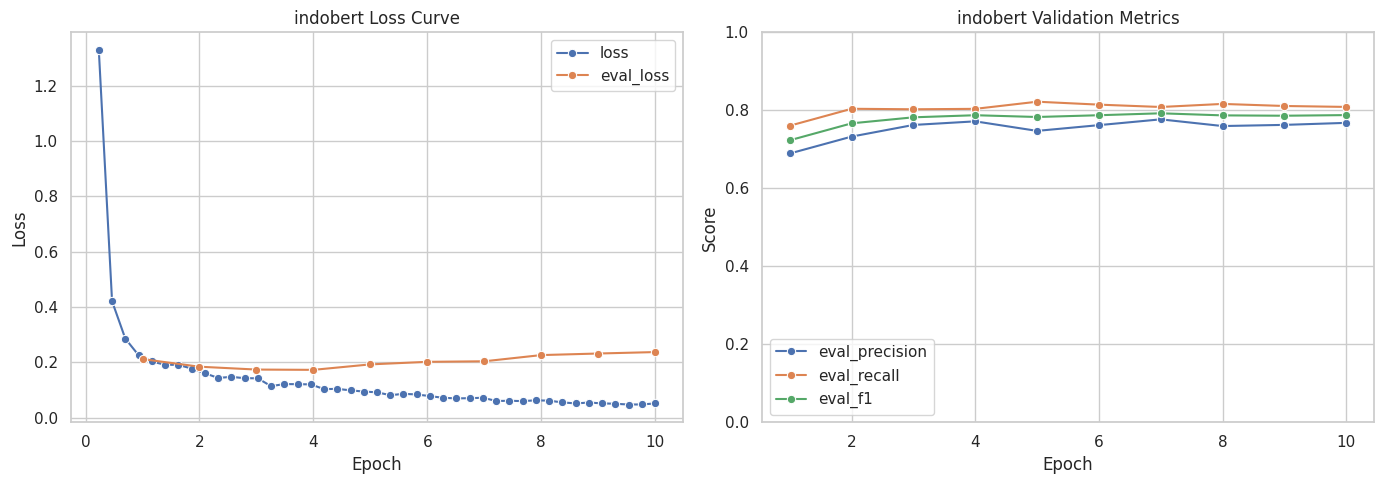

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


  Cleanup: hapus checkpoint-1505
  Cleanup: hapus HF cache models--indobenchmark--indobert-large-p2
              precision    recall  f1-score   support

      HSkill     0.6627    0.6886    0.6754      1949
      SSkill     0.7951    0.8333    0.8138       852
        Tech     0.8445    0.8678    0.8560      2541

   micro avg     0.7699    0.7969    0.7832      5342
   macro avg     0.7674    0.7966    0.7817      5342
weighted avg     0.7703    0.7969    0.7834      5342


=== Training nusabert: LazarusNLP/NusaBERT-large ===


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at LazarusNLP/NusaBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_23/1160713879.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Hskill,Precision Hskill,Recall Hskill,F1 Sskill,Precision Sskill,Recall Sskill,F1 Tech,Precision Tech,Recall Tech
1,0.218300,0.217192,0.698741,0.781428,0.737775,0.643033,0.596973,0.696795,0.766986,0.739666,0.796402,0.822050,0.788790,0.858239
2,0.179600,0.197697,0.725752,0.821488,0.770658,0.683053,0.620759,0.759244,0.793551,0.752761,0.839015,0.853990,0.833782,0.875202
3,0.141400,0.182642,0.754776,0.807911,0.780440,0.696982,0.674481,0.721035,0.823095,0.803427,0.843750,0.844108,0.812710,0.878029
4,0.121000,0.182943,0.790420,0.788300,0.789359,0.693229,0.696680,0.689811,0.828491,0.820037,0.837121,0.866748,0.869212,0.864297
5,0.095000,0.201834,0.754057,0.809923,0.780992,0.702766,0.668148,0.741167,0.817930,0.798736,0.838068,0.844366,0.824231,0.865509
6,0.081600,0.211011,0.766134,0.803889,0.784558,0.700923,0.685243,0.717338,0.818600,0.796595,0.841856,0.852129,0.832435,0.872779
7,0.069000,0.218316,0.774532,0.804392,0.789179,0.705100,0.692125,0.718570,0.815874,0.795680,0.837121,0.860548,0.846755,0.874798


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

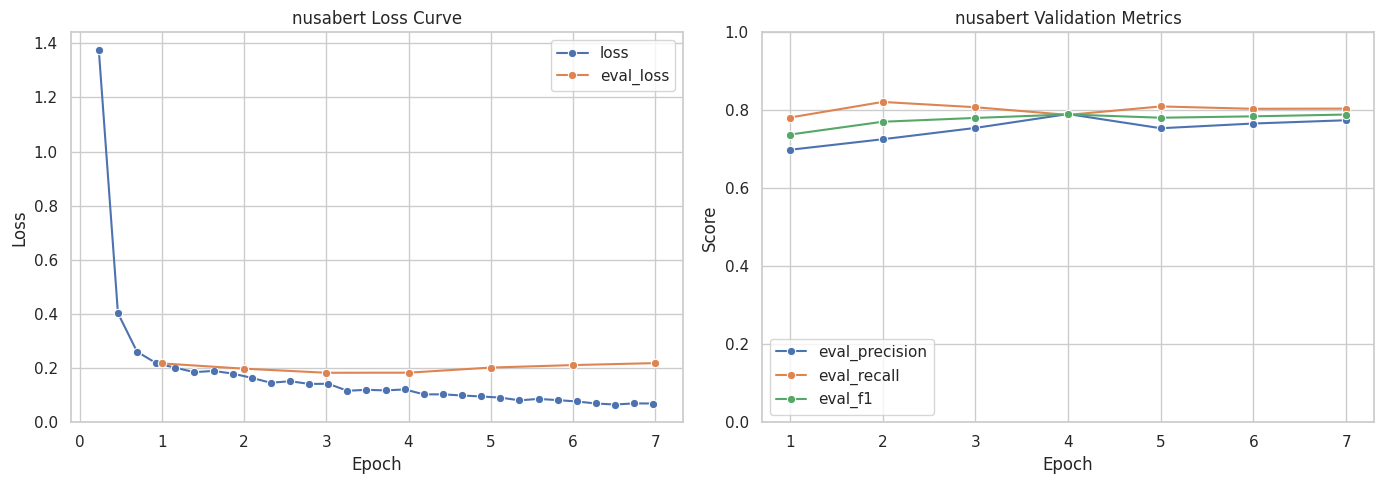

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


  Cleanup: hapus checkpoint-860
  Cleanup: hapus HF cache models--LazarusNLP--NusaBERT-large
              precision    recall  f1-score   support

      HSkill     0.7095    0.6949    0.7021      2288
      SSkill     0.7905    0.8602    0.8239       930
        Tech     0.8584    0.8567    0.8575      2498

   micro avg     0.7884    0.7925    0.7904      5716
   macro avg     0.7861    0.8039    0.7945      5716
weighted avg     0.7878    0.7925    0.7899      5716



,run_name,model_name,best_model_dir,train_time_seconds,train_loss,validation_loss,validation_precision,validation_recall,validation_f1,validation_f1_HSkill,...,test_f1_SSkill,test_precision_SSkill,test_recall_SSkill,test_f1_Tech,test_precision_Tech,test_recall_Tech,test_runtime,test_samples_per_second,test_steps_per_second,test_epoch
0,indobert,indobenchmark/indobert-large-p2,/kaggle/working/outputs/models/indobert-best,17267.314430,0.141173,0.204075,0.77682,0.80853,0.792358,0.683021,...,0.813754,0.795073,0.833333,0.855978,0.844504,0.867769,7.3127,58.802,1.914,10.0
1,nusabert,LazarusNLP/NusaBERT-large,/kaggle/working/outputs/models/nusabert-best,12142.271031,0.176892,0.182943,0.79042,0.78830,0.789359,0.693229,...,0.823893,0.790514,0.860215,0.857544,0.858404,0.856685,7.3157,58.778,1.914,7.0


In [19]:
all_metrics = []

for run_name, model_name in MODEL_CONFIGS.items():
    metrics = train_one_model(run_name, model_name)
    all_metrics.append(metrics)

comparison_df = pd.DataFrame(all_metrics)
comparison_df.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
(REPORTS_DIR / "model_comparison.json").write_text(comparison_df.to_json(orient="records", indent=2), encoding="utf-8")
display(comparison_df)

## 18. Visualisasi Perbandingan Model

Cell ini membuat grafik perbandingan precision, recall, dan F1 pada test set. Grafik ini bisa langsung dimasukkan ke laporan atau slide.

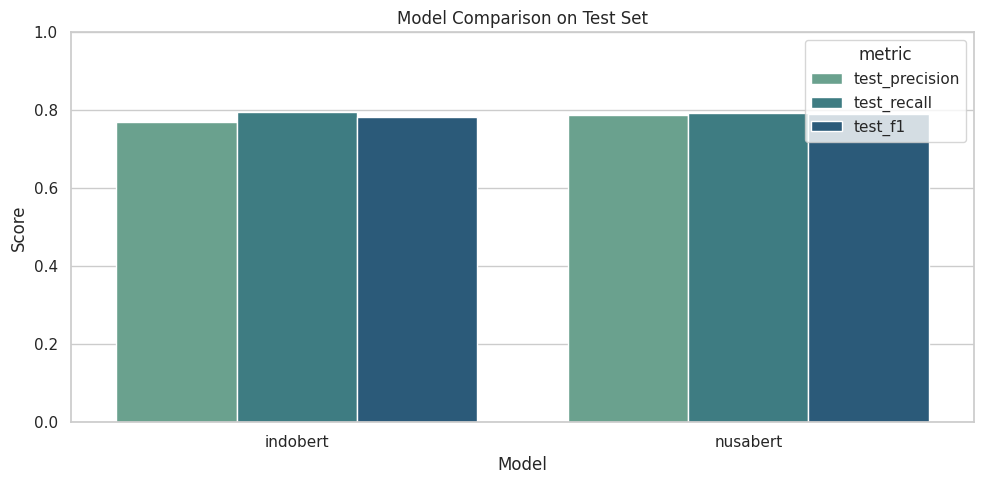

,run_name,model_name,best_model_dir,train_time_seconds,train_loss,validation_loss,validation_precision,validation_recall,validation_f1,validation_f1_HSkill,...,test_f1_SSkill,test_precision_SSkill,test_recall_SSkill,test_f1_Tech,test_precision_Tech,test_recall_Tech,test_runtime,test_samples_per_second,test_steps_per_second,test_epoch
1,nusabert,LazarusNLP/NusaBERT-large,/kaggle/working/outputs/models/nusabert-best,12142.271031,0.176892,0.182943,0.79042,0.78830,0.789359,0.693229,...,0.823893,0.790514,0.860215,0.857544,0.858404,0.856685,7.3157,58.778,1.914,7.0
0,indobert,indobenchmark/indobert-large-p2,/kaggle/working/outputs/models/indobert-best,17267.314430,0.141173,0.204075,0.77682,0.80853,0.792358,0.683021,...,0.813754,0.795073,0.833333,0.855978,0.844504,0.867769,7.3127,58.802,1.914,10.0


In [20]:
metric_cols = ["test_precision", "test_recall", "test_f1"]
plot_df = comparison_df[["run_name", *metric_cols]].melt(id_vars="run_name", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="run_name", y="score", hue="metric", palette="crest")
plt.title("Model Comparison on Test Set")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison.png", dpi=180)
plt.show()

display(comparison_df.sort_values("test_f1", ascending=False))

## 19. Cek Underfitting dan Overfitting

Cell ini membaca training history dan memberi flag sederhana. Keputusan akhir tetap perlu dilihat dari grafik, tetapi flag ini membantu membuat pembahasan laporan lebih sistematis.

In [21]:
def diagnose_training(run_name: str) -> dict[str, object]:
    history_path = REPORTS_DIR / f"training_history_{run_name}.csv"
    history = pd.read_csv(history_path)
    eval_rows = history.dropna(subset=["eval_f1"]) if "eval_f1" in history.columns else pd.DataFrame()
    if eval_rows.empty:
        return {"run_name": run_name, "status": "no_eval_history"}

    best_eval_f1 = float(eval_rows["eval_f1"].max())
    last_eval_f1 = float(eval_rows["eval_f1"].iloc[-1])
    best_epoch = float(eval_rows.loc[eval_rows["eval_f1"].idxmax(), "epoch"])
    last_eval_loss = float(eval_rows["eval_loss"].iloc[-1]) if "eval_loss" in eval_rows else math.nan
    best_eval_loss = float(eval_rows["eval_loss"].min()) if "eval_loss" in eval_rows else math.nan

    possible_underfit = best_eval_f1 < 0.60
    possible_overfit = (best_eval_f1 - last_eval_f1) > 0.03 or (not math.isnan(last_eval_loss) and last_eval_loss > best_eval_loss * 1.20)

    return {
        "run_name": run_name,
        "best_epoch": best_epoch,
        "best_eval_f1": best_eval_f1,
        "last_eval_f1": last_eval_f1,
        "possible_underfit": possible_underfit,
        "possible_overfit": possible_overfit,
    }


diagnostics_df = pd.DataFrame([diagnose_training(run_name) for run_name in MODEL_CONFIGS])
diagnostics_df.to_csv(REPORTS_DIR / "fit_diagnostics.csv", index=False)
display(diagnostics_df)

,run_name,best_epoch,best_eval_f1,last_eval_f1,possible_underfit,possible_overfit
0,indobert,7.0,0.792358,0.787733,False,True
1,nusabert,4.0,0.789359,0.789179,False,False


## 20. Pilih Model Terbaik

Model terbaik dipilih berdasarkan `test_f1`. Jika selisih F1 kecil, pertimbangkan stabilitas per entity, ukuran model, dan inference time untuk web ONNX.

In [22]:
best_row = comparison_df.sort_values("test_f1", ascending=False).iloc[0]
best_run_name = best_row["run_name"]
best_model_dir = Path(best_row["best_model_dir"])

best_model_info = {
    "best_run_name": best_run_name,
    "best_model_dir": str(best_model_dir),
    "selection_metric": "test_f1",
    "test_f1": float(best_row["test_f1"]),
}
(OUTPUT_DIR / "best_model.json").write_text(json.dumps(best_model_info, indent=2), encoding="utf-8")

print(json.dumps(best_model_info, indent=2))

{
  "best_run_name": "nusabert",
  "best_model_dir": "/kaggle/working/outputs/models/nusabert-best",
  "selection_metric": "test_f1",
  "test_f1": 0.790437968940848
}


## 21. Error Analysis Model Terbaik

Error analysis membantu menjelaskan kelemahan model. Cell ini mengambil sampel kalimat test yang prediksinya berbeda dari label gold, lalu menyimpan tabel untuk laporan.

In [23]:
def get_sentence_predictions(model_dir: Path, limit: int = 80) -> pd.DataFrame:
    tokenizer, tokenized_dataset = tokenize_and_align_dataset(raw_dataset, str(model_dir), MAX_LENGTH)
    model = AutoModelForTokenClassification.from_pretrained(model_dir)
    trainer = Trainer(
        model=model,
        args=TrainingArguments(output_dir=str(OUTPUT_DIR / "tmp_predict"), report_to="none", per_device_eval_batch_size=16),
        tokenizer=tokenizer,
        data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    )
    predictions, labels, _ = trainer.predict(tokenized_dataset["test"])
    pred_labels, gold_labels = decode_predictions(predictions, labels)

    rows = []
    for idx, (pred, gold, raw) in enumerate(zip(pred_labels, gold_labels, test_records)):
        if pred != gold:
            rows.append({
                "test_index": idx,
                "sentence": " ".join(raw["tokens"]),
                "gold_labels": " ".join(gold),
                "pred_labels": " ".join(pred),
            })
        if len(rows) >= limit:
            break
    return pd.DataFrame(rows)


error_df = get_sentence_predictions(best_model_dir, limit=80)
error_df.to_csv(REPORTS_DIR / "error_analysis_samples.csv", index=False)
display(error_df.head(20))

Map:   0%|          | 0/3439 [00:00<?, ? examples/s]

Map:   0%|          | 0/430 [00:00<?, ? examples/s]

Map:   0%|          | 0/430 [00:00<?, ? examples/s]

/tmp/ipykernel_23/2789959489.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


,test_index,sentence,gold_labels,pred_labels
0,0,"Laki-laki , Usia Maksimal 3o tahun Pendidikan ...",O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
1,1,PT Surabaya Industrial Estate Rungkut ( SIER )...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
2,2,PT HoME CENTER INDoNESIA/Lowongan Analisis Dat...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
3,3,PT Surya Mastrindo . Software Engineer . Jakar...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
4,4,PT CIPTA KARYA TECHNoLoGY/ Lowongan Project Ma...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
5,5,Deskripsi Pekerjaan Mampu menjalin kedekatan e...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
6,6,"PT Senja Karya Rotindo Kabupaten Karawang , PT...",O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
7,7,"PT Untung Bersama Sejahtera , Surabaya , Net W...",O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
8,8,Bhinneka.com . Senior Software Engineer . Jaka...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...
9,9,PT . Global Service Indonesia/IT Programmer.Ja...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...


## 22. Export Model Terbaik ke ONNX FP32

ONNX FP32 digunakan sebagai baseline deployment. Pada tahap ini akurasi seharusnya tidak berubah signifikan karena bobot belum di-quantize.

In [24]:
onnx_fp32_dir = ONNX_DIR / "fp32"
onnx_fp32_dir.mkdir(parents=True, exist_ok=True)

ort_model = ORTModelForTokenClassification.from_pretrained(best_model_dir, export=True)
best_tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
ort_model.save_pretrained(onnx_fp32_dir)
best_tokenizer.save_pretrained(onnx_fp32_dir)

label_map = {"label_list": LABEL_LIST, "label2id": LABEL2ID, "id2label": ID2LABEL}
(onnx_fp32_dir / "label_map.json").write_text(json.dumps(label_map, indent=2), encoding="utf-8")

onnx_files = list(onnx_fp32_dir.glob("*.onnx"))
if not onnx_files:
    raise FileNotFoundError(f"Tidak ada file ONNX di {onnx_fp32_dir}")
onnx_fp32_path = onnx_files[0]
print("ONNX FP32:", onnx_fp32_path, f"{onnx_fp32_path.stat().st_size / (1024 ** 2):.2f} MB")

`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


ONNX FP32: /kaggle/working/outputs/onnx/fp32/model.onnx 1280.78 MB


## 23. Quantization ONNX

Dynamic quantization dibuat untuk menurunkan ukuran model. Model quantized hanya dipakai untuk web jika hasil validasi tetap stabil.

In [25]:
onnx_quantized_dir = ONNX_DIR / "quantized"
onnx_quantized_dir.mkdir(parents=True, exist_ok=True)
onnx_quantized_path = onnx_quantized_dir / "model_quantized.onnx"

quantize_dynamic(str(onnx_fp32_path), str(onnx_quantized_path), weight_type=QuantType.QInt8)

for file_name in ["tokenizer.json", "vocab.txt", "tokenizer_config.json", "special_tokens_map.json", "config.json", "label_map.json"]:
    source_file = onnx_fp32_dir / file_name
    if source_file.exists():
        shutil.copy2(source_file, onnx_quantized_dir / file_name)

size_report = {
    "fp32_mb": onnx_fp32_path.stat().st_size / (1024 ** 2),
    "quantized_mb": onnx_quantized_path.stat().st_size / (1024 ** 2),
}
(REPORTS_DIR / "onnx_size_report.json").write_text(json.dumps(size_report, indent=2), encoding="utf-8")
print(json.dumps(size_report, indent=2))

# Hapus FP32 ONNX dir setelah quantization berhasil (hemat ~1.3 GB)
print("Cleanup: hapus ONNX FP32 dir (quantized sudah tersedia)")
shutil.rmtree(onnx_fp32_dir, ignore_errors=True)

{
  "fp32_mb": 1280.779764175415,
  "quantized_mb": 321.74871921539307
}
Cleanup: hapus ONNX FP32 dir (quantized sudah tersedia)


## 24. Siapkan Folder Model untuk Web

Cell ini membuat folder `web_model` yang nantinya disalin ke proyek lokal `web/model`. Default yang dipilih adalah ONNX quantized karena lebih ringan. Jika nanti validasi menunjukkan hasilnya turun terlalu jauh, gunakan ONNX FP32.

In [26]:
WEB_MODEL_DIR.mkdir(parents=True, exist_ok=True)
preferred_onnx = onnx_quantized_path if onnx_quantized_path.exists() else onnx_fp32_path
shutil.copy2(preferred_onnx, WEB_MODEL_DIR / "model.onnx")

asset_source_dir = onnx_quantized_dir if preferred_onnx == onnx_quantized_path else onnx_fp32_dir
for file_name in ["tokenizer.json", "vocab.txt", "tokenizer_config.json", "special_tokens_map.json", "config.json", "label_map.json"]:
    source_file = asset_source_dir / file_name
    if source_file.exists():
        shutil.copy2(source_file, WEB_MODEL_DIR / file_name)

print("Web model folder:", WEB_MODEL_DIR)
print("Files:")
for path in sorted(WEB_MODEL_DIR.iterdir()):
    print("-", path.name, f"{path.stat().st_size / (1024 ** 2):.2f} MB")

Web model folder: /kaggle/working/outputs/web_model
Files:
- config.json 0.00 MB
- label_map.json 0.00 MB
- model.onnx 321.75 MB
- special_tokens_map.json 0.00 MB
- tokenizer.json 0.94 MB
- tokenizer_config.json 0.25 MB
- vocab.txt 0.22 MB


## 25. Final Checklist Output

Cell terakhir memastikan file penting untuk laporan, slide, dan web demo sudah terbentuk. Download `/kaggle/working/outputs` setelah notebook selesai.

In [27]:
expected_outputs = [
    OUTPUT_DIR / "dataset_stats.json",
    REPORTS_DIR / "model_comparison.csv",
    REPORTS_DIR / "fit_diagnostics.csv",
    REPORTS_DIR / "error_analysis_samples.csv",
    OUTPUT_DIR / "best_model.json",
    WEB_MODEL_DIR / "model.onnx",
    WEB_MODEL_DIR / "label_map.json",
]

checklist = pd.DataFrame({
    "path": [str(path) for path in expected_outputs],
    "exists": [path.exists() for path in expected_outputs],
})
display(checklist)

if not checklist["exists"].all():
    missing = checklist.loc[~checklist["exists"], "path"].tolist()
    raise FileNotFoundError(f"Output belum lengkap: {missing}")

print("Notebook selesai. Download /kaggle/working/outputs dan salin outputs/web_model ke web/model lokal.")

,path,exists
0,/kaggle/working/outputs/dataset_stats.json,True
1,/kaggle/working/outputs/reports/model_comparis...,True
2,/kaggle/working/outputs/reports/fit_diagnostic...,True
3,/kaggle/working/outputs/reports/error_analysis...,True
4,/kaggle/working/outputs/best_model.json,True
5,/kaggle/working/outputs/web_model/model.onnx,True
6,/kaggle/working/outputs/web_model/label_map.json,True


Notebook selesai. Download /kaggle/working/outputs dan salin outputs/web_model ke web/model lokal.
